In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, MultiLabelBinarizer
import kagglehub
import os
import missingno as msno

# Make a figures folders if does not exist
os.makedirs("figures", exist_ok=True)
# Download latest version
path = kagglehub.dataset_download("ashyou09/indian-patient-disease-and-treatment-dataset")

print("Path to dataset files:", path)

# Optional: Prevent text truncation inside cells
pd.set_option('display.max_colwidth', None)

Path to dataset files: /Users/yugamdeepgoyal/.cache/kagglehub/datasets/ashyou09/indian-patient-disease-and-treatment-dataset/versions/1


In [2]:
# df = pd.read_csv("indian_diseases_dataset.csv")
df = pd.read_csv(os.path.join(path, "indian_diseases_dataset.csv"))
df.head()

,patient_id,age,age_group,gender,state,city,region,urban_rural,disease_name,disease_category,...,insurance_status,treatment_type,hospital_type,days_hospitalized,treatment_cost_inr,outcome,death_flag,cause_of_death,recovery_days,follow_up_required
0,IND-00000001,70,70-79,Female,Bihar,Patna,East,Semi-Urban,Diarrhea,Waterborne,...,Employer,Medication,Government,21,102.0,Recovering,0,NaN,42.0,Yes
1,IND-00000002,27,20-29,Other,Gujarat,Surat,West,Urban,Chikungunya,Vector-Borne,...,Uninsured,Medication,Government,0,1151.0,Recovered,0,NaN,18.0,Yes
2,IND-00000003,66,60-69,Other,Jharkhand,Bokaro,East,Rural,Hypertension,Non-Communicable,...,Private,Medication,Government,2,89.0,Chronic Management,0,NaN,NaN,Yes
3,IND-00000004,27,20-29,Female,Karnataka,Hubli,South,Rural,Tuberculosis,Infectious,...,Private,Surgery,Government,9,1269.0,Recovering,0,NaN,69.0,Yes
4,IND-00000005,40,40-49,Male,Karnataka,Belagavi,South,Rural,Chronic Kidney Disease,Non-Communicable,...,Ayushman Bharat,Palliative,Private,31,670576.0,Deceased,1,Complications from Chronic Kidney Disease,NaN,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          20000 non-null  str    
 1   age                 20000 non-null  int64  
 2   age_group           20000 non-null  str    
 3   gender              20000 non-null  str    
 4   state               20000 non-null  str    
 5   city                20000 non-null  str    
 6   region              20000 non-null  str    
 7   urban_rural         20000 non-null  str    
 8   disease_name        20000 non-null  str    
 9   disease_category    20000 non-null  str    
 10  severity            20000 non-null  str    
 11  diagnosis_date      20000 non-null  str    
 12  year                20000 non-null  int64  
 13  month               20000 non-null  str    
 14  season              20000 non-null  str    
 15  symptoms            20000 non-null  str    
 16  comorbidity    

In [4]:
df.isna().sum()[df.isna().sum()>0].sort_values(ascending=False)

cause_of_death    18178
alcohol_use        6627
comorbidity        6599
recovery_days      6307
dtype: int64

In [5]:
len(df[(df["recovery_days"].isna()) & (df["death_flag"] == 1)])

1822

In [6]:
df["comorbidity"] = df["comorbidity"].fillna("No comorbidity")

In [7]:
df_raw = df.copy()

# EDA SECTION

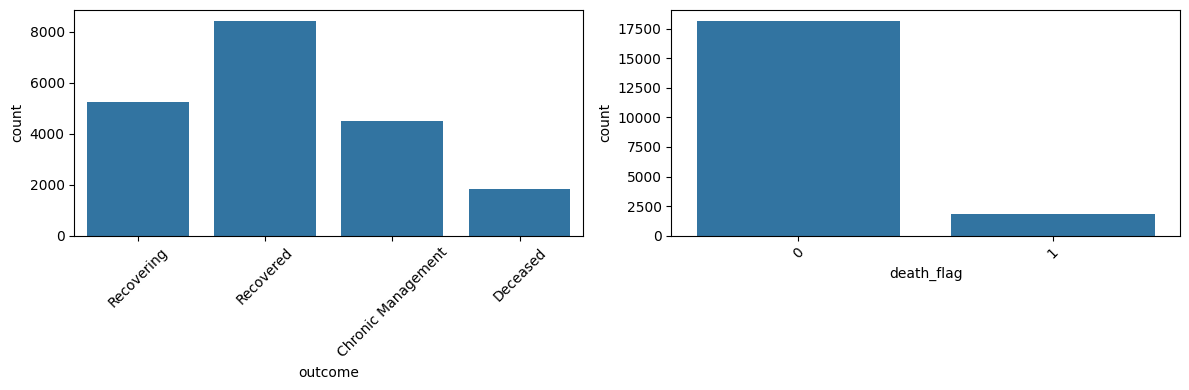

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df_raw["outcome"], ax=axes[0])
axes[0].tick_params(axis='x', labelrotation=45)

sns.countplot(x=df_raw["death_flag"], ax=axes[1])
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig("figures/outcome_count_death_count.png")
plt.show()

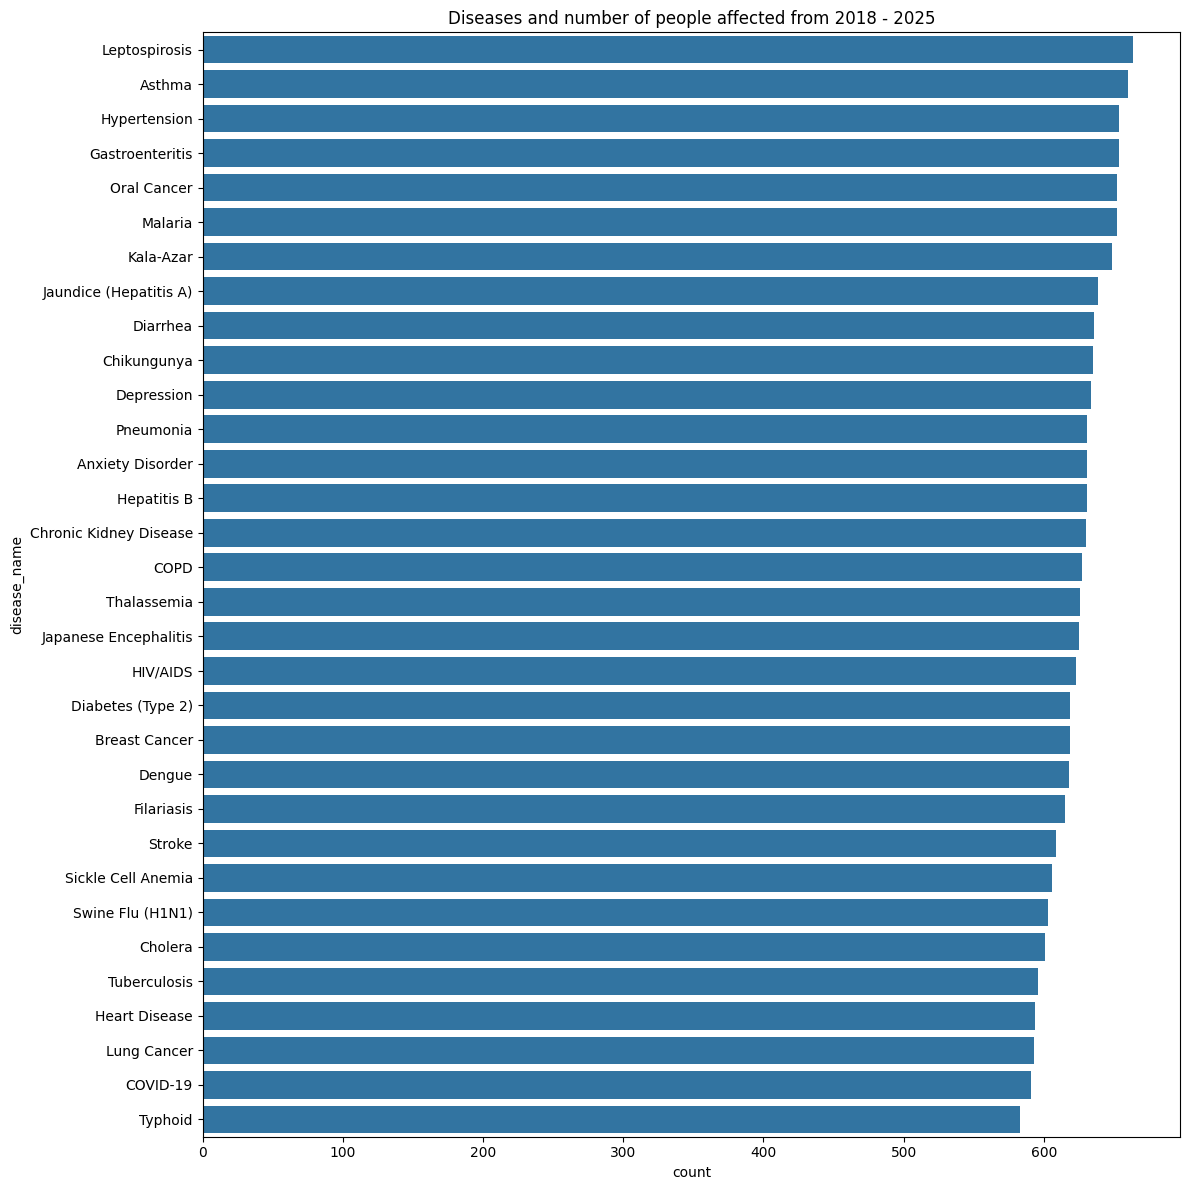

In [9]:
plt.figure(figsize=(12,12))
plt.title("Diseases and number of people affected from 2018 - 2025")
sns.countplot(data=df_raw, y='disease_name', order=df_raw['disease_name'].value_counts().index)
plt.tight_layout()
plt.savefig("figures/diseases_and_number_of_people_affected.png")
plt.show()

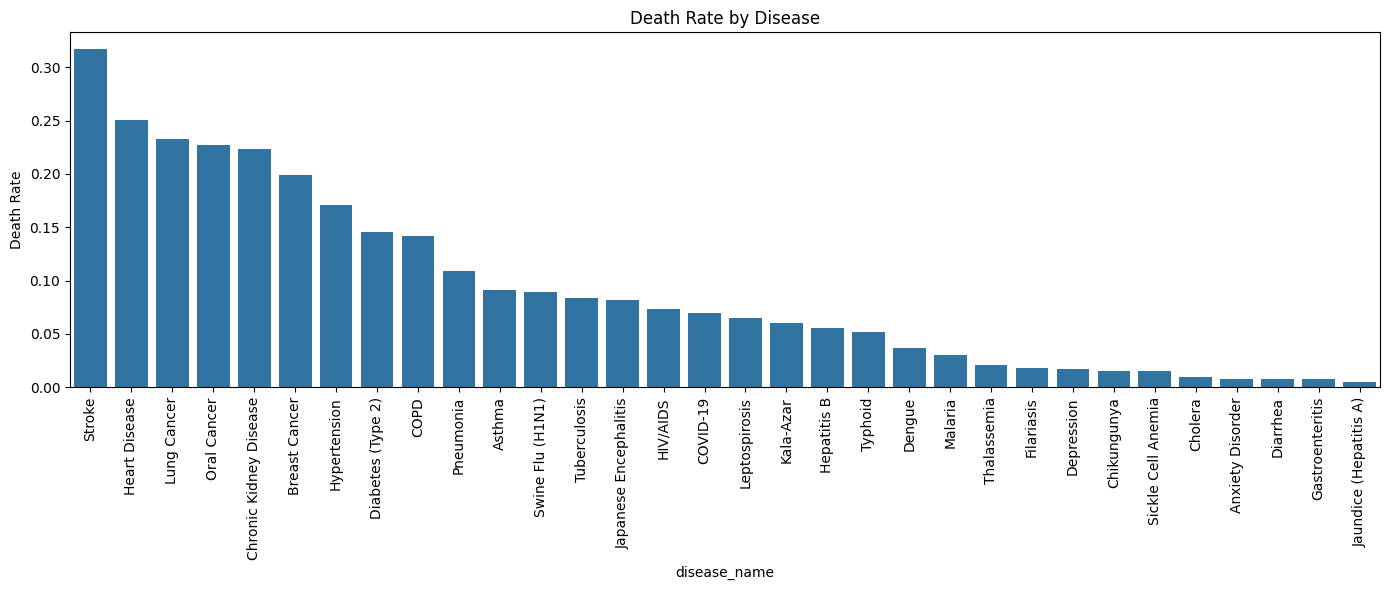

In [10]:
death_rate = df_raw.groupby('disease_name')['death_flag'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
sns.barplot(x=death_rate.index, y=death_rate.values)
plt.xticks(rotation=90)
plt.ylabel('Death Rate')
plt.title('Death Rate by Disease')
plt.tight_layout()
plt.savefig("figures/death_rate_by_disease.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

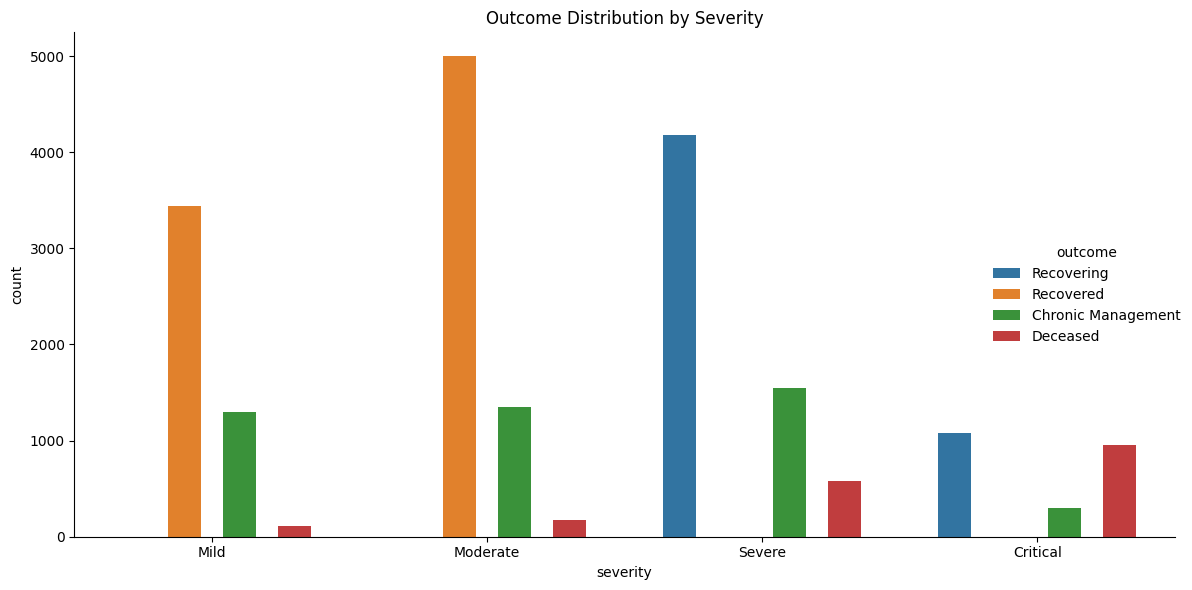

In [11]:
plt.figure(figsize=(10,6))
# sns.countplot(x=df_raw["severity"], hue=df_raw["outcome"], order=['Mild', 'Moderate', 'Severe', 'Critical'])
sns.catplot(
    data=df_raw, 
    x="severity", 
    hue="outcome", 
    order=['Mild', 'Moderate', 'Severe', 'Critical'],
    kind="count",
    gap=0.4, # Adjust this value (0 to 1) to increase/decrease the gap between hue bars
    height=6, 
    aspect=1.66 # Keeps the roughly 10:6 aspect ratio
)
plt.title('Outcome Distribution by Severity')
plt.tight_layout()
plt.savefig("figures/outcome_distribution_by_severity.png")
plt.show()

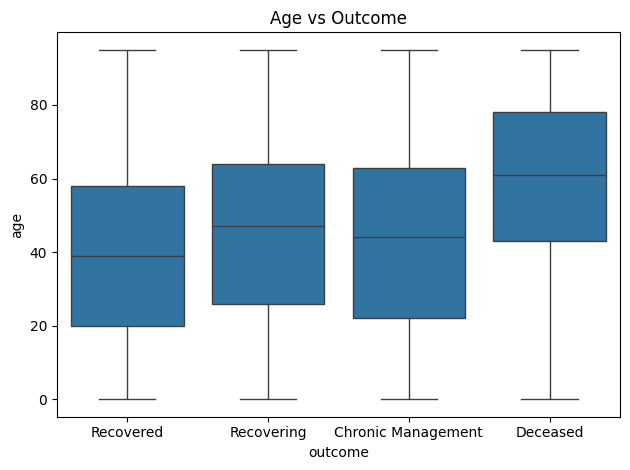

In [12]:
sns.boxplot(x=df_raw["outcome"], y=df_raw["age"], order=['Recovered','Recovering','Chronic Management','Deceased'])
plt.title("Age vs Outcome")
plt.tight_layout()
plt.savefig("figures/ages_vs_outcome.png")
plt.show()

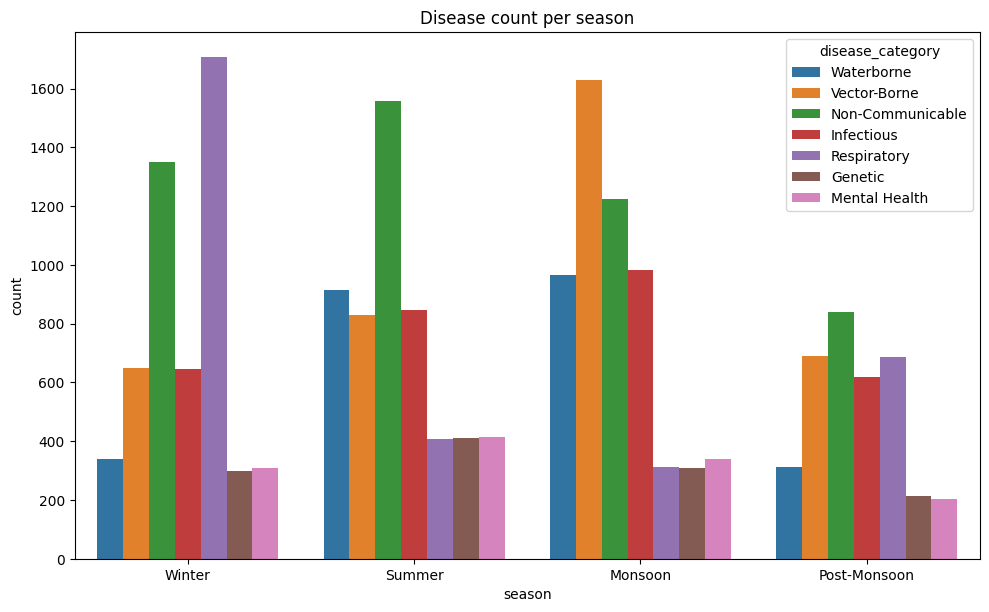

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(x=df_raw["season"], hue=df_raw["disease_category"])
plt.tight_layout()
plt.title("Disease count per season")
plt.savefig("figures/season_disease_category.png")
plt.show()

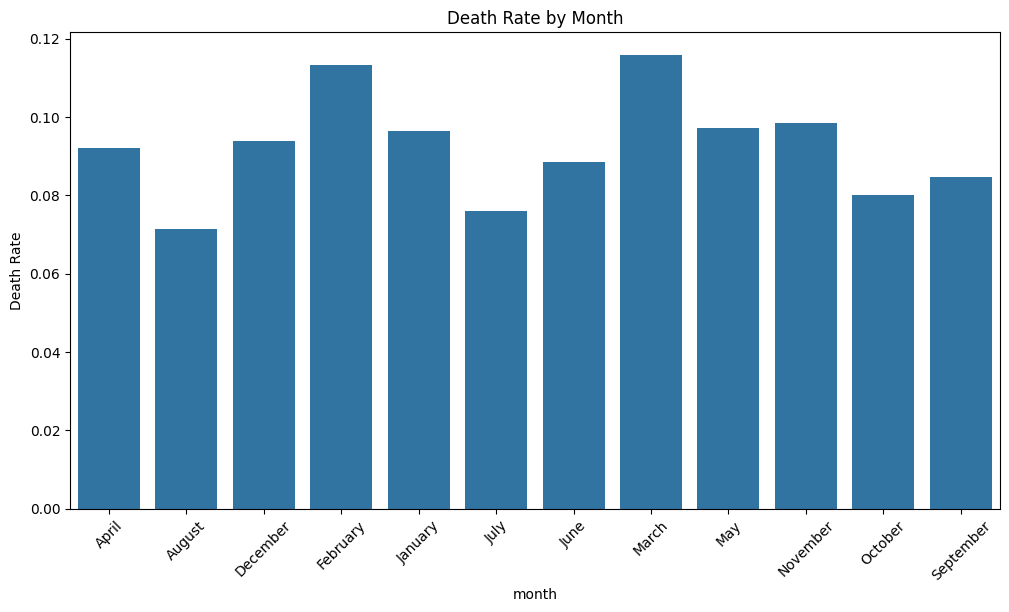

In [14]:
# sns.countplot(x=df_raw["season"], hue=df_raw["death_flag"].mean())
plt.figure(figsize=(10,6))
data = df_raw.groupby("month")["death_flag"].mean()
sns.barplot(x=data.index, y=data.values)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel("Death Rate")
plt.title("Death Rate by Month")
plt.savefig("figures/death_rate_by_month.png")
plt.show()

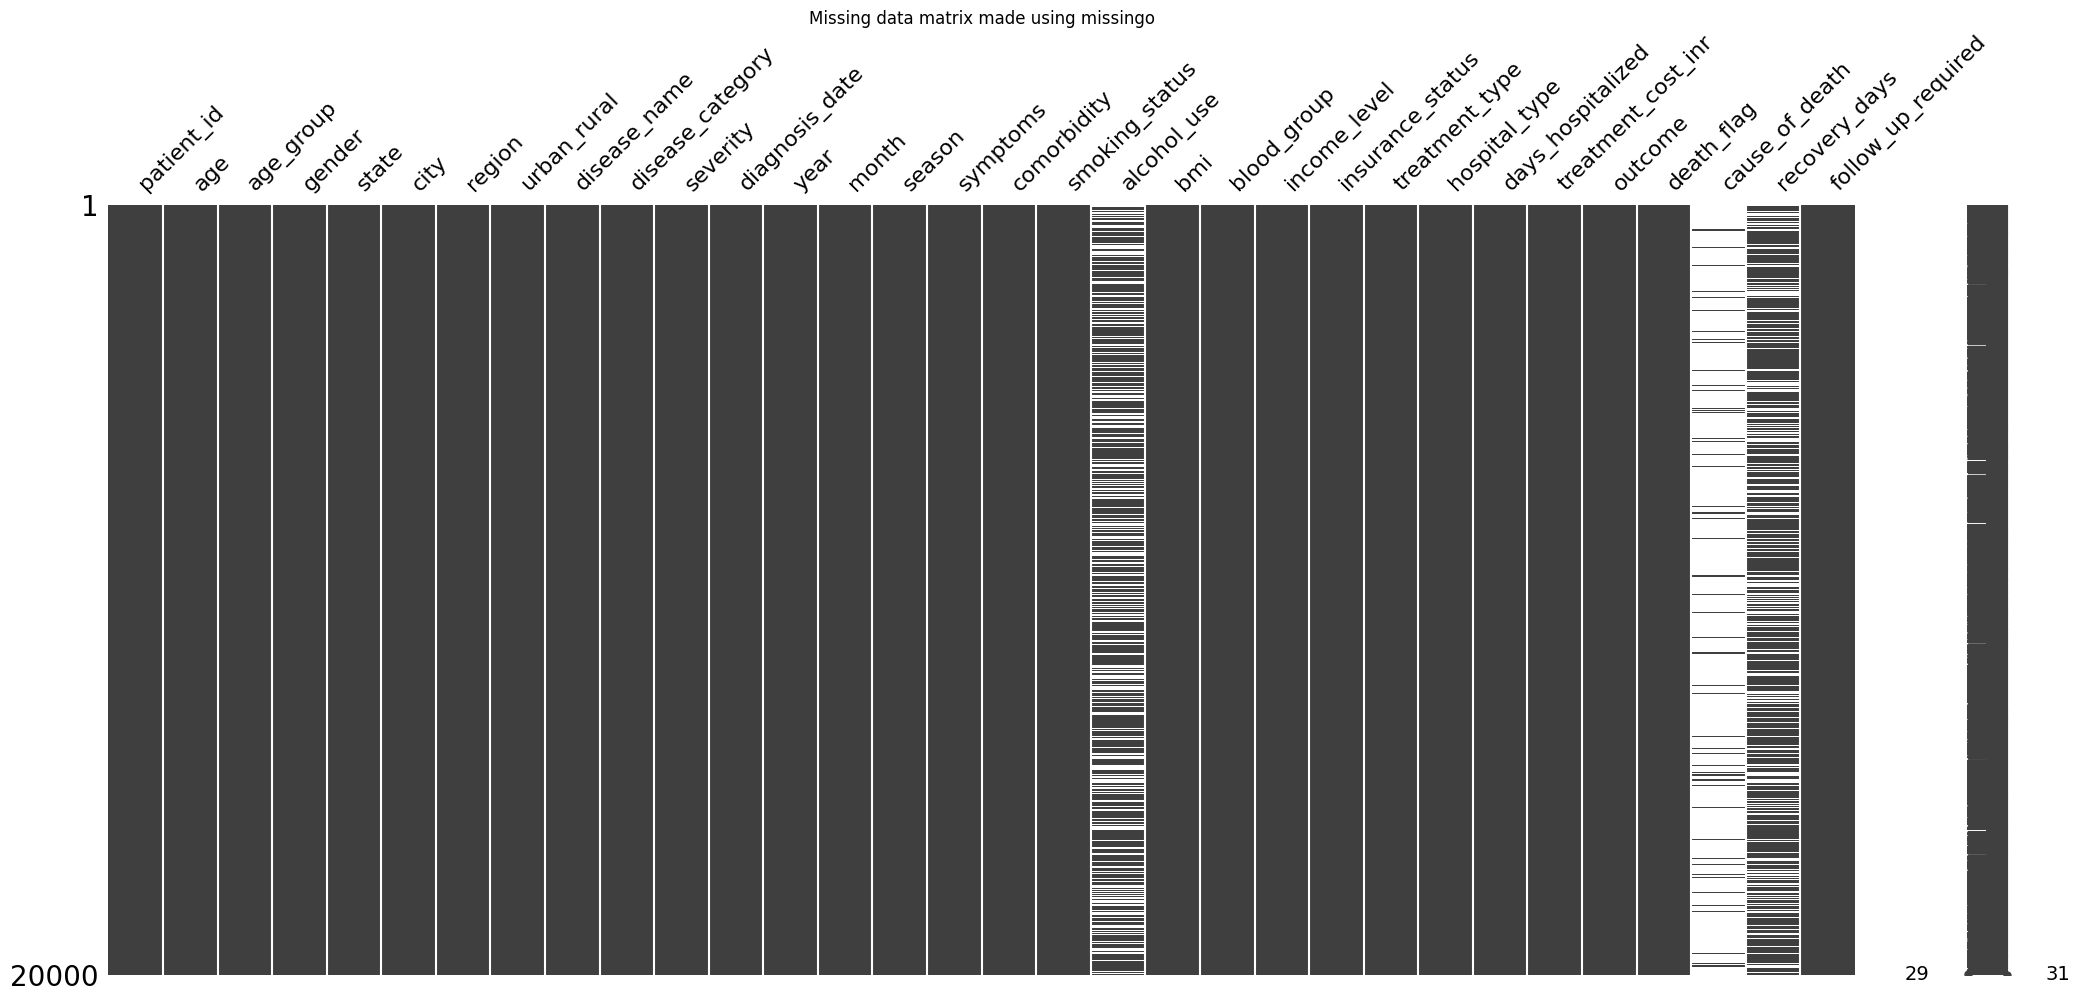

In [15]:
msno.matrix(df_raw)
plt.title("Missing data matrix made using missingo")
plt.savefig("figures/missing_data_matrix.png")
plt.show()

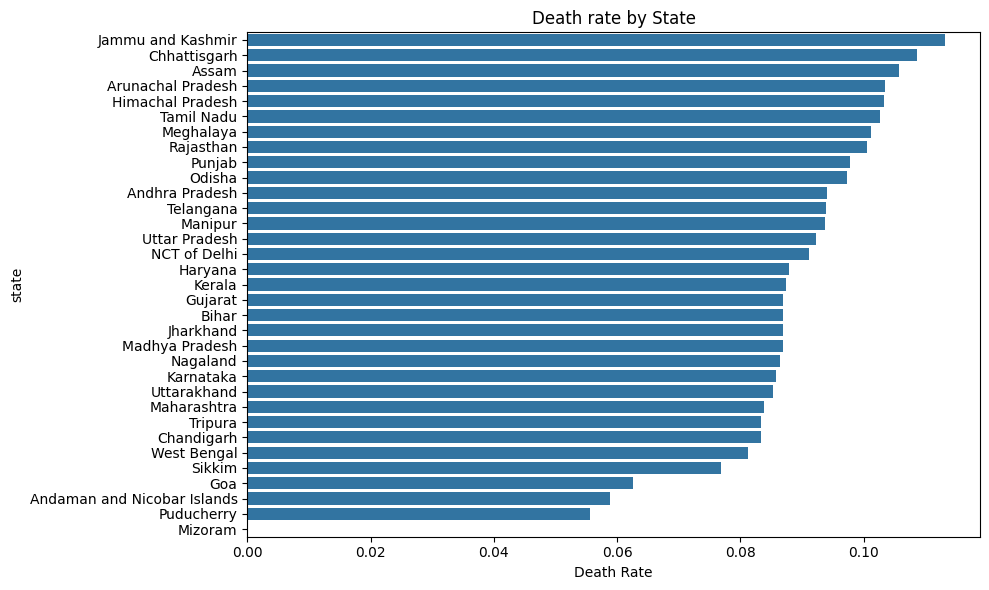

In [16]:
death_rate_state = df_raw.groupby("state")["death_flag"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(y=death_rate_state.index, x=death_rate_state.values)
plt.title("Death rate by State")
plt.xlabel("Death Rate")
plt.tight_layout()
plt.savefig("figures/death_rate_by_state.png")
plt.show()

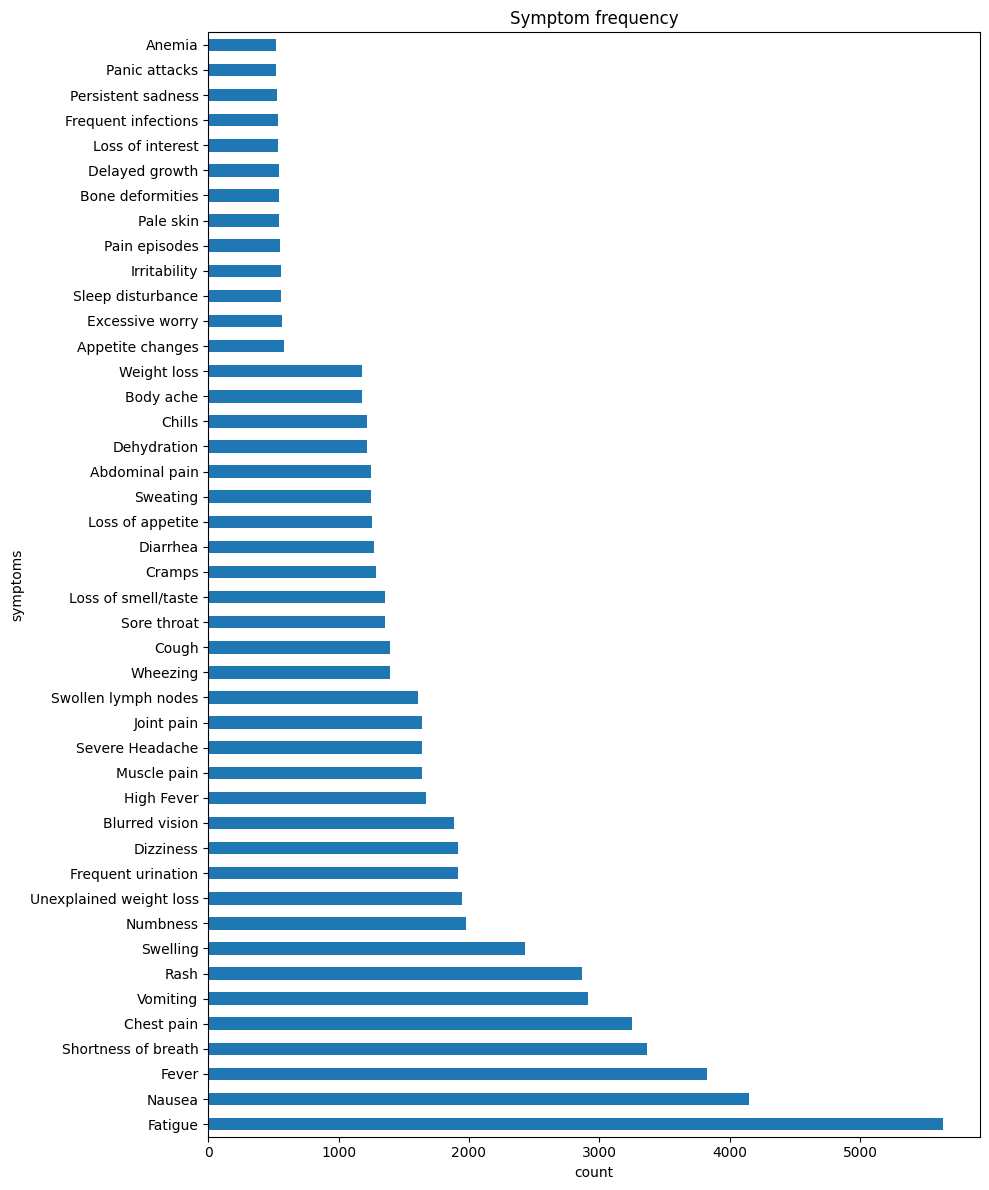

In [17]:
# Which symptoms appear most — validates your MultiLabelBinarizer approach
plt.figure(figsize=(10,10))
plt.title("Which symptoms appear most in the dataset?")
symptom_counts = df_raw['symptoms'].str.split(', ').explode().value_counts()
symptom_counts.plot(kind='barh', figsize=(10, 12), title='Symptom frequency')
plt.xlabel("count")
plt.tight_layout()
plt.savefig("figures/symptoms_frequency.png")
plt.show()

In [18]:
gender_encoder = LabelEncoder()
df["gender"] = gender_encoder.fit_transform(df["gender"])

In [19]:
df["alcohol_use"].unique()

<ArrowStringArray>
[nan, 'Regular', 'Occasional', 'Heavy']
Length: 4, dtype: str

In [20]:
categories = {
    "Occasional": 1,
    "Regular": 2,
    "Heavy": 3
}
df["alcohol_use"] = df["alcohol_use"].map(categories)

In [21]:
# As cause_of_death column is mostly empty so dropping this column is necessary
df = df.drop(columns=["cause_of_death"])

In [22]:
disease_encoder = LabelEncoder()
df["disease_name"] = disease_encoder.fit_transform(df["disease_name"])

In [23]:
df["disease_category"].unique()

<ArrowStringArray>
[      'Waterborne',     'Vector-Borne', 'Non-Communicable',
       'Infectious',      'Respiratory',          'Genetic',
    'Mental Health']
Length: 7, dtype: str

In [24]:
disease_category_encoder = LabelEncoder()
df["disease_category"] = disease_category_encoder.fit_transform(df["disease_category"])

In [25]:
df["blood_group"].unique()

<ArrowStringArray>
['A+', 'O+', 'B+', 'O-', 'A-', 'AB+', 'B-', 'AB-']
Length: 8, dtype: str

In [26]:
blood_encoder = LabelEncoder()
df["blood_group"] = blood_encoder.fit_transform(df["blood_group"])

In [27]:
df = df.drop(columns="city")

In [28]:
# region_order = {'Northeast':1, 'East':2, 'North':3,
#                 'Central':4, 'West':5, 'South':6}
# urban_order  = {'Rural':1, 'Semi-Urban':2, 'Urban':3}
region_encoder = LabelEncoder()
df['region']      = region_encoder.fit_transform(df['region'])
urban_rural_encoder = LabelEncoder()
df['urban_rural'] = urban_rural_encoder.fit_transform(df['urban_rural'])


In [29]:
state_encoder = LabelEncoder()
df['state'] = state_encoder.fit_transform(df['state'])

In [30]:
df["severity"].unique()

<ArrowStringArray>
['Severe', 'Mild', 'Critical', 'Moderate']
Length: 4, dtype: str

In [31]:
severity_category = [["Mild", "Moderate", "Severe", "Critical"]]
severity_encoder = OrdinalEncoder(categories=severity_category)
df["severity"] = severity_encoder.fit_transform(df[["severity"]]).astype(int)

In [32]:
df["severity"].unique()

array([2, 0, 3, 1])

In [33]:
df["income_level"].unique()

<ArrowStringArray>
['Middle', 'High', 'Below Poverty Line', 'Lower', 'Upper-Middle']
Length: 5, dtype: str

In [34]:
df["smoking_status"].unique()

<ArrowStringArray>
['Never', 'Former', 'Current']
Length: 3, dtype: str

In [35]:
smoking_categories = [["Never", "Former", "Current"]]
smoking_encoder = OrdinalEncoder(categories=smoking_categories)
df["smoking_status"] = smoking_encoder.fit_transform(df[["smoking_status"]]).astype(int)

In [36]:
month_encoder = LabelEncoder()
df["month"] = month_encoder.fit_transform(df["month"])

In [37]:
season_categories = {
    "Summer": 1,
    "Monsoon": 2,
    "Post-Monsoon": 3,
    "Winter": 4
}
df["season"] = df["season"].map(season_categories)

In [38]:
df["income_level"].unique()
income_categories = [["Below Poverty Line", "Lower", "Middle", "Upper-Middle", "High"]]
income_encoder = OrdinalEncoder(categories=income_categories)
df["income_level"] = income_encoder.fit_transform(df[["income_level"]]).astype(int)

In [39]:
symptom_list = df["symptoms"].str.split(", ")
mlb = MultiLabelBinarizer()
symptom_df = pd.DataFrame(mlb.fit_transform(symptom_list), columns=mlb.classes_)
df = pd.concat((df, symptom_df), axis=1)
df = df.drop(columns=["symptoms"])

In [40]:
df = df.drop(columns=["diagnosis_date"])

In [41]:
df = df.drop(columns=["patient_id", "age_group"])

In [42]:
insurance_status_encoder = LabelEncoder()
df["insurance_status"] = insurance_status_encoder.fit_transform(df["insurance_status"])

In [43]:
hospital_encoder = LabelEncoder()
df["hospital_type"] = hospital_encoder.fit_transform(df["hospital_type"])

In [44]:
# There is not any specific category possible because chronic management patients equal to recovering so I will use label encoding
outcome_encoder = LabelEncoder()
df["outcome"] = outcome_encoder.fit_transform(df["outcome"])

In [45]:
comorbidity_encoder = LabelEncoder()
df["comorbidity"] = comorbidity_encoder.fit_transform(df["comorbidity"])

In [46]:
# Because I am planning to predict death_flag and outcome from XGBoost which I will implement after learning so that's why I am dropping these columns
df = df.drop(columns=["treatment_type", "recovery_days", "days_hospitalized", "follow_up_required", "treatment_cost_inr"])

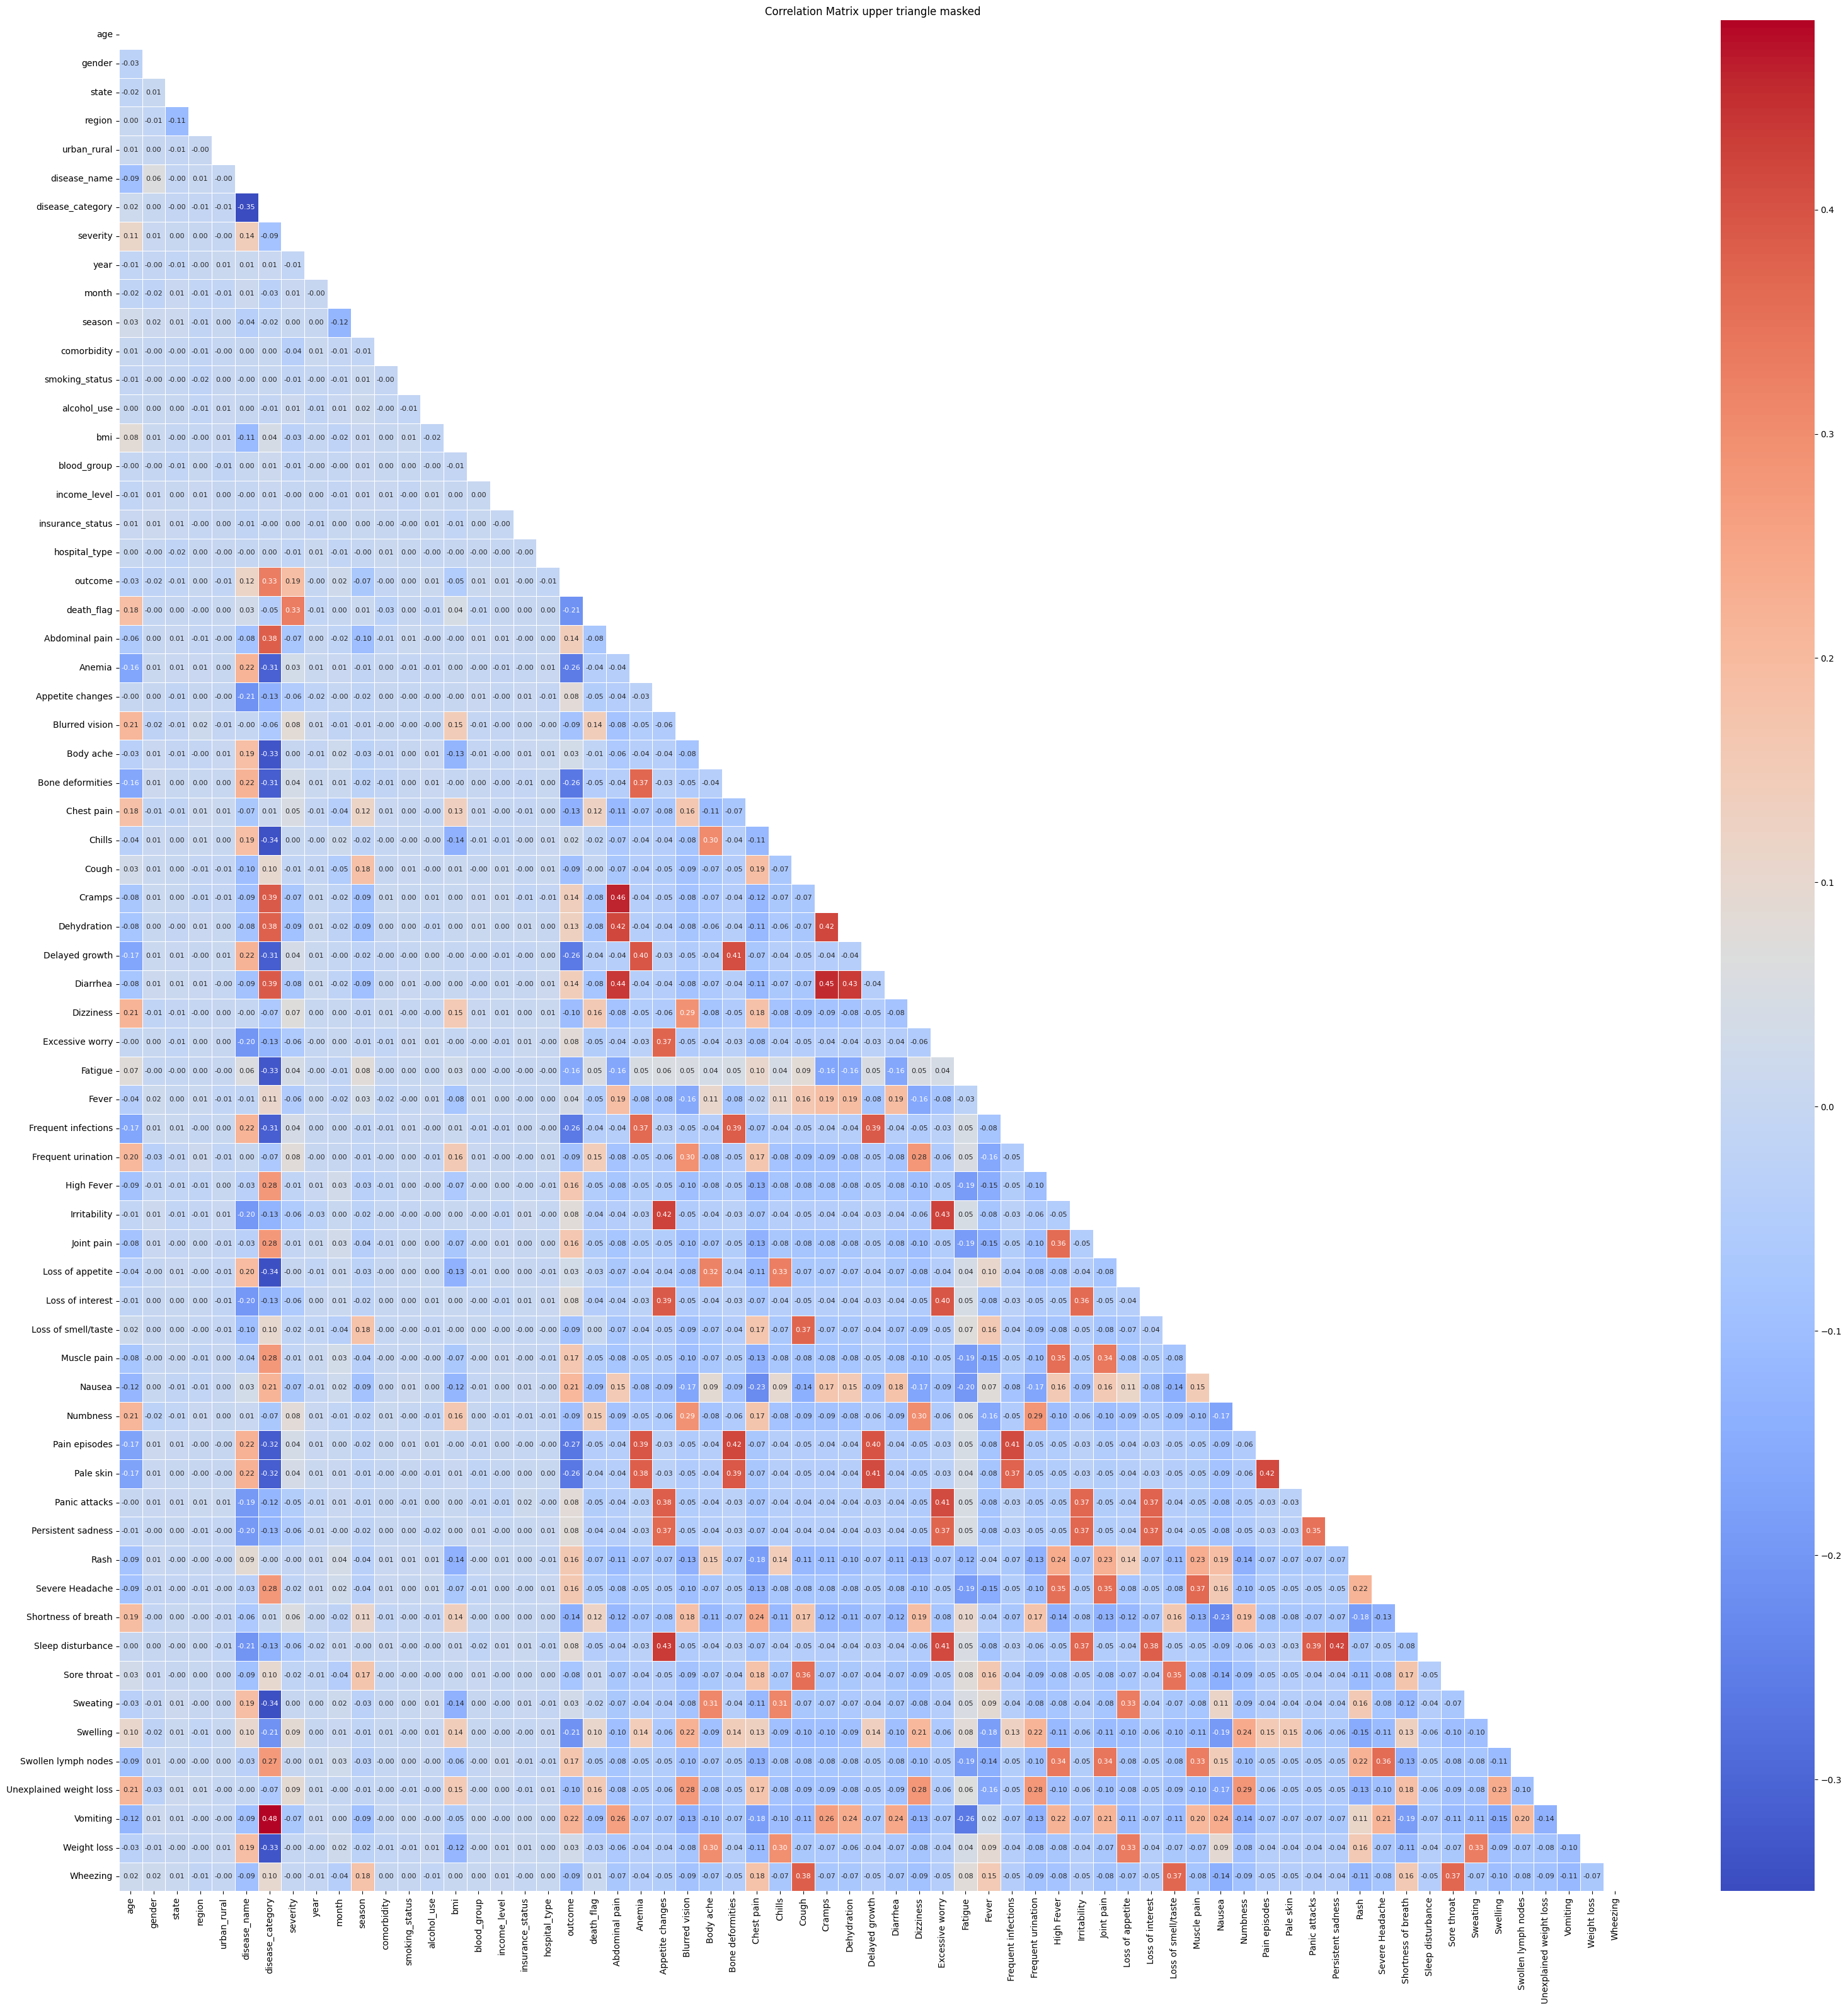

In [47]:
corr = df.corr()

plt.figure(figsize=(32,32))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Matrix upper triangle masked')
plt.tight_layout()
plt.show()

In [48]:
corr_with_target = df.corr()["death_flag"].drop("death_flag")
pd.set_option("display.max_rows", None)
corr_with_target.abs().sort_values(ascending=False)

severity                   0.328108
outcome                    0.211264
age                        0.184761
Unexplained weight loss    0.157780
Dizziness                  0.156630
Numbness                   0.151483
Frequent urination         0.145327
Blurred vision             0.141618
Chest pain                 0.124550
Shortness of breath        0.120976
Swelling                   0.103513
Vomiting                   0.094729
Nausea                     0.094664
Diarrhea                   0.076174
Abdominal pain             0.075853
Cramps                     0.075834
Dehydration                0.075499
Rash                       0.067031
Fever                      0.052477
Muscle pain                0.051685
High Fever                 0.051549
Fatigue                    0.051473
Joint pain                 0.049567
Severe Headache            0.048978
Swollen lymph nodes        0.048968
Excessive worry            0.047633
Panic attacks              0.047413
Appetite changes           0

In [49]:
pd.reset_option('display.max_rows')

In [50]:
X = df.drop(columns=["death_flag", "outcome"])
y = df[["death_flag", "outcome"]]
X.to_csv("X.csv", index=False)
y.to_csv("y.csv", index=False)

In [51]:
# EDA FINDINGS SUMMARY
# Add this as the final cell in app.ipynb

print("EDA & PREPROCESSING SUMMARY")

#Target Distribution
print("\nTARGET DISTRIBUTION")
outcome_counts = df_raw["outcome"].value_counts()
for outcome, count in outcome_counts.items():
    print(f"  {outcome:<25} {count:>5} ({count/len(df_raw)*100:.1f}%)")
print(f"\n  Overall death rate: {df_raw['death_flag'].mean()*100:.2f}%")

#Deadliest Diseases
print("\nTOP 5 DEADLIEST DISEASES")
death_by_disease = df_raw.groupby("disease_name")["death_flag"].mean().sort_values(ascending=False)
for disease, rate in death_by_disease.head(5).items():
    print(f"  {disease:<30} {rate*100:.1f}%")

print("\n5 LOWEST MORTALITY DISEASES")
for disease, rate in death_by_disease.tail(5).items():
    print(f"  {disease:<30} {rate*100:.1f}%")

#Severity Impact
print("\nSEVERITY vs DEATH RATE")
sev_death = df_raw.groupby("severity")["death_flag"].mean().reindex(["Mild","Moderate","Severe","Critical"])
for sev, rate in sev_death.items():
    print(f"  {sev:<12} {rate*100:>5.1f}%")

#Age by Outcome
print("\nMEAN AGE BY OUTCOME")
age_outcome = df_raw.groupby("outcome")["age"].mean().sort_values(ascending=False)
for outcome, age in age_outcome.items():
    print(f"  {outcome:<25} {age:.1f} years")
print("  → Deceased patients are 18.6 years older than Recovered on average")

#Seasonal Patterns
print("\nSEASONAL DEATH RATE")
season_death = df_raw.groupby("season")["death_flag"].mean().sort_values(ascending=False)
for season, rate in season_death.items():
    print(f"  {season:<15} {rate*100:.2f}%")
print("  → Monsoon: highest Vector-borne disease burden (1,629 cases)")
print("  → Winter: highest death rate (10.08%) — cardiac & respiratory peak")

#Monthly Death Rate
print("\nMONTHLY DEATH RATE (Top 3 / Bottom 3)")
month_death = df_raw.groupby("month")["death_flag"].mean().sort_values(ascending=False)
print("  Highest:")
for month, rate in month_death.head(3).items():
    print(f"    {month:<12} {rate*100:.2f}%")
print("  Lowest:")
for month, rate in month_death.tail(3).items():
    print(f"    {month:<12} {rate*100:.2f}%")

#Geographic
print("\nDEATH RATE BY STATE (Top 3 / Bottom 3)")
state_death = df_raw.groupby("state")["death_flag"].mean().sort_values(ascending=False)
print("  Highest:")
for state, rate in state_death.head(3).items():
    print(f"    {state:<30} {rate*100:.2f}%")
print("  Lowest:")
for state, rate in state_death.tail(3).items():
    print(f"    {state:<30} {rate*100:.2f}%")

#Top Symptoms
print("\nTOP 10 SYMPTOMS BY FREQUENCY")
symptom_counts = df_raw["symptoms"].str.split(", ").explode().value_counts()
for symptom, count in symptom_counts.head(10).items():
    print(f"  {symptom:<30} {count:>5} patients")

# ── Final Dataset Info ───────────────────────────────────────
print("\nFINAL DATASET")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape} --> death_flag + outcome")
print(f"  Saved: X.csv, y.csv, processed_df.csv")

print("FUTURE PLAN IS TO USE XGBOOST TO PREDICT death_flag AND outcome")

EDA & PREPROCESSING SUMMARY

TARGET DISTRIBUTION
  Recovered                  8440 (42.2%)
  Recovering                 5253 (26.3%)
  Chronic Management         4485 (22.4%)
  Deceased                   1822 (9.1%)

  Overall death rate: 9.11%

TOP 5 DEADLIEST DISEASES
  Stroke                         31.7%
  Heart Disease                  25.1%
  Lung Cancer                    23.3%
  Oral Cancer                    22.7%
  Chronic Kidney Disease         22.4%

5 LOWEST MORTALITY DISEASES
  Cholera                        1.0%
  Anxiety Disorder               0.8%
  Diarrhea                       0.8%
  Gastroenteritis                0.8%
  Jaundice (Hepatitis A)         0.5%

SEVERITY vs DEATH RATE
  Mild           2.4%
  Moderate       2.6%
  Severe         9.2%
  Critical      41.0%

MEAN AGE BY OUTCOME
  Deceased                  58.7 years
  Recovering                45.5 years
  Chronic Management        44.0 years
  Recovered                 40.1 years
  → Deceased patients are 